In [ ]:
import pickle
import sys
import warnings
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "ipynb file").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.metrics import auc, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score

from src.model import build_model_pipeline, evaluate_model

warnings.filterwarnings("ignore")

prep_path = project_root / "ipynb file" / "03_preprocessing.ipynb"
print(f"Running preprocessing notebook: {prep_path}")
%run "{prep_path}"

model_names = ["Logistic Regression", "KNN", "SVM", "Decision Tree", "Random Forest"]
models = {name: build_model_pipeline(name, X_train) for name in model_names}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1")
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test)
    results.append(
        {
            "Model": name,
            "CV_F1_Mean": cv_scores.mean(),
            "CV_F1_Std": cv_scores.std(),
            "Accuracy": metrics["accuracy"],
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1_Score": metrics["f1"],
            "ROC_AUC": metrics["roc_auc"],
        }
    )

model_comparison = pd.DataFrame(results).sort_values(by="F1_Score", ascending=False)
print(model_comparison)
print("\nBest Model based on F1 Score:")
best_model_name = model_comparison.iloc[0]["Model"]
print(best_model_name)

c:\Users\pradi\Pradip Workspace\The IOT acadamy assignment\AI ML Internship Programe\Telco Customer Churn\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running preprocessing notebook: C:\Users\pradi\Pradip Workspace\The IOT acadamy assignment\AI ML Internship Programe\Telco Customer Churn\ipynb file\03_preprocessing.ipynb
Columns after dropping:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Engineered columns added: ['tenure_group', 'monthly_charge_per_tenure']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'monthly_charge_per_tenure']
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'tenure_group']
Target labels: ['No' 'Yes']
Encoded

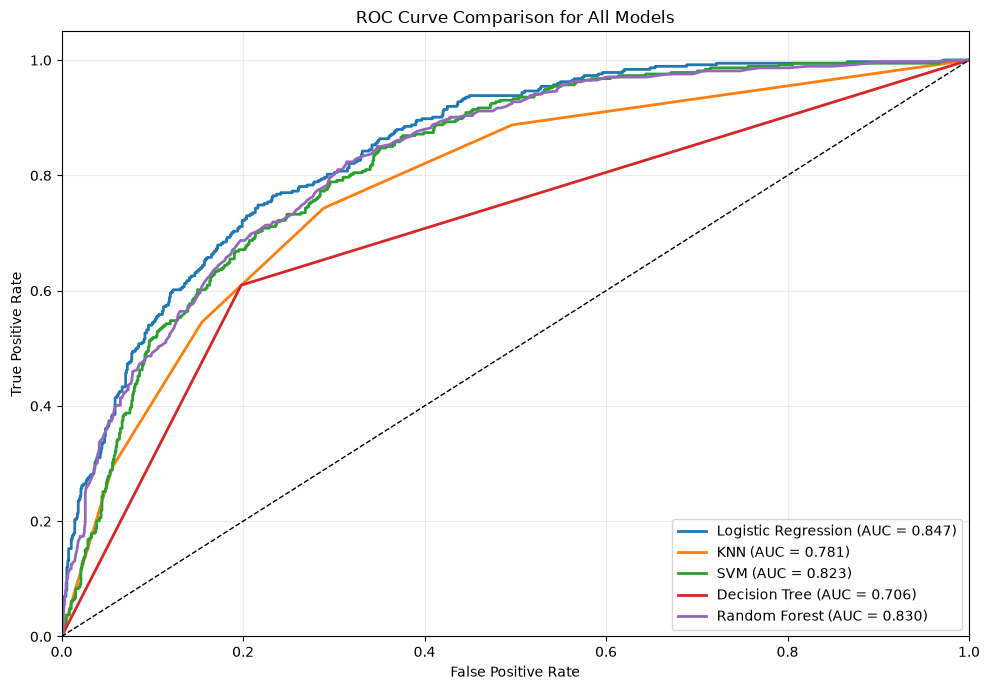

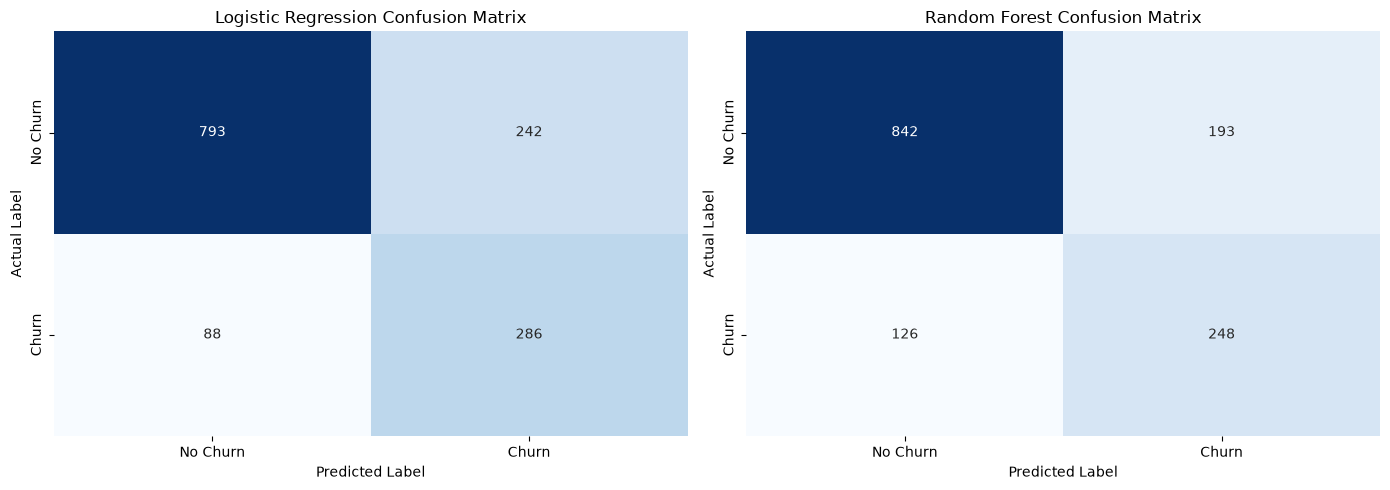


Best model by F1 Score: Logistic Regression
Fitting 5 folds for each of 18 candidates, totalling 90 fits


Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.



Tuned model: Logistic Regression
Best params: {'model__solver': 'liblinear', 'model__penalty': 'l2', 'model__C': 0.5}
Test ROC AUC: 0.8468

Target reached: Test ROC AUC >= 0.80
Aim is 0.85+, continue tuning if needed.


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

<Figure size 1000x600 with 0 Axes>

In [ ]:
# Compare ROC curves for the baseline pipelines.
plt.figure(figsize=(10, 7))
for name, model in models.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    score = auc(false_positive_rate, true_positive_rate)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC = {score:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Show confusion matrices for the two highest-F1 baseline models.
top_two = model_comparison.head(2)["Model"].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, model_name in zip(axes, top_two):
    predictions = models[model_name].predict(X_test)
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"],
        cbar=False,
        ax=axis,
    )
    axis.set_title(f"{model_name} Confusion Matrix")
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("Actual Label")
plt.tight_layout()
plt.show()

# Tune the best baseline model using cross-validation.
best_model = models[best_model_name]
parameter_distributions = {
    "Logistic Regression": {
        "model__C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 20],
        "model__solver": ["liblinear", "lbfgs"],
        "model__penalty": ["l2"],
    },
    "KNN": {
        "model__n_neighbors": list(range(1, 31)),
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "SVM": {
        "model__C": [0.1, 0.5, 1, 2, 5, 10, 20],
        "model__gamma": ["scale", "auto", 0.01, 0.1, 1],
        "model__kernel": ["rbf", "linear", "poly"],
    },
    "Decision Tree": {
        "model__max_depth": [None, 2, 3, 4, 5, 6, 8, 10, 12, 15],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [None, 5, 8, 10, 15, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
        "model__bootstrap": [True, False],
    },
}

random_search = RandomizedSearchCV(
    estimator=best_model,
    param_distributions=parameter_distributions[best_model_name],
    n_iter=25,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
random_search.fit(X_train, y_train)
best_tuned_model = random_search.best_estimator_
y_proba_tuned = best_tuned_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_proba_tuned)
print(f"\nTuned model: {best_model_name}")
print(f"Best parameters: {random_search.best_params_}")
print(f"Test ROC AUC: {test_auc:.4f}")

# Explain the fitted classifier using the same transformed features it received during training.
preprocessor = best_tuned_model.named_steps["preprocessing"]
model_for_shap = best_tuned_model.named_steps["model"]
feature_names = preprocessor.named_steps["encoding"].get_feature_names_out()
train_transformed = preprocessor.transform(X_train)
test_transformed = preprocessor.transform(X_test)
if hasattr(train_transformed, "toarray"):
    train_transformed = train_transformed.toarray()
if hasattr(test_transformed, "toarray"):
    test_transformed = test_transformed.toarray()
train_transformed = pd.DataFrame(train_transformed, columns=feature_names)
test_transformed = pd.DataFrame(test_transformed, columns=feature_names)
explainer = shap.Explainer(model_for_shap, train_transformed)
shap_values = explainer(test_transformed)
shap.summary_plot(shap_values, test_transformed, max_display=15)
shap.plots.waterfall(shap_values[0], max_display=15)

# Save the fitted pipeline and its evaluation summary.
model_dir = project_root / "models"
model_dir.mkdir(exist_ok=True)
final_payload = {
    "model": best_tuned_model,
    "feature_names": list(X_train.columns),
    "best_model_name": best_model_name,
    "best_params": random_search.best_params_,
    "test_roc_auc": float(test_auc),
}
with open(model_dir / "churn_model_v1.pkl", "wb") as model_file:
    pickle.dump(final_payload, model_file)

final_metrics = evaluate_model(best_tuned_model, X_test, y_test)
model_card = f"""# Customer Churn Prediction Model Card

## Model Selected
- Best model by baseline F1 score: {best_model_name}
- Tuned using RandomizedSearchCV
- Test ROC-AUC: {test_auc:.4f}

## Evaluation Metrics
- Accuracy: {final_metrics['accuracy']:.4f}
- Precision: {final_metrics['precision']:.4f}
- Recall: {final_metrics['recall']:.4f}
- F1 score: {final_metrics['f1']:.4f}
- ROC-AUC: {final_metrics['roc_auc']:.4f}

## Business Use
The model can help prioritize at-risk customers for retention outreach. Predictions should support, not replace, customer-service judgment.

## Risks and Limitations
Performance depends on data quality and customer behavior remaining representative. Monitor for data drift and review fairness before operational use.
"""
(model_dir / "model_card.md").write_text(model_card, encoding="utf-8")
print(f"Model saved to: {model_dir / 'churn_model_v1.pkl'}")
print(f"Model card saved to: {model_dir / 'model_card.md'}")

In [ ]:
X_train